# Plantalyze model
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

Notebook para probar el modelo y realizar predicciones.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub
from sklearn import metrics
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Hiperparámetros

In [2]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

### Importar dataset

In [3]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

100%|██████████| 1.34G/1.34G [00:34<00:00, 41.4MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/plants-classification/versions/1


In [4]:
test_dir = path + "/test"

Found 6000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

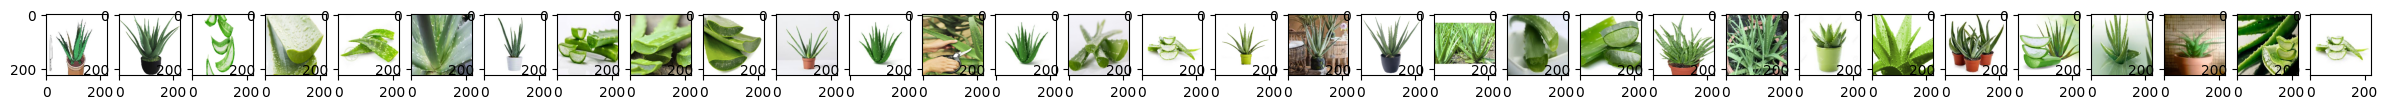

In [5]:
datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

images , labels = test_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

### Carga del modelo

In [6]:
def upload_model(path):
  model = load_model(path)
  return model

#### Carga y preprocesamiento de la imagen

In [7]:
def upload_image(path):
  img = image.load_img(
      path, target_size=(IMG_WIDTH, IMG_HEIGHT)
  )
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0
  img_array = tf.expand_dims(img_array, 0)
  return img_array

#### Predicción e interpretación

In [13]:
def predict_image(model, path, true_class):
  class_names = {}
  for key, value in test_generator.class_indices.items():
    class_names[value] = key

  image = upload_image(path)
  prediction = model.predict(image)

  class_name = class_names[np.argmax(prediction)]
  prediction_prob = np.max(prediction) * 100

  print("Clase real: ", true_class)
  print(f"Clase predicha: {class_name}")
  print(f"Confianza: {prediction_prob:.2f}%")
  print("\nDistribución de probabilidades:")
  for index, probability in enumerate(prediction[0]):
    if probability >= 0.0001:
      print(f"{class_names[index]}: {probability * 100:.2f}%")

#### Predicción y resultados

In [16]:
model = upload_model('/content/drive/MyDrive/Plantalyze/checkpoints/best_model_arq2_v4.keras')
real_class = 'watermelon'
predict_image(model, '/content/drive/MyDrive/Plantalyze/watermelon.jpg', real_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
Clase real:  watermelon
Clase predicha: watermelon
Confianza: 99.89%

Distribución de probabilidades:
guava: 0.08%
melon: 0.02%
watermelon: 99.89%


In [10]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)

188/188 ━━━━━━━━━━━━━━━━━━━━ 131s 690ms/step - accuracy: 0.6690 - loss: 1.1909
Test accuracy: 0.6690000295639038
Test loss: 1.1909258365631104
188/188 ━━━━━━━━━━━━━━━━━━━━ 129s 686ms/step


In [11]:
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

Classification Report:
               precision    recall  f1-score   support

     aloevera       0.83      0.70      0.76       200
       banana       0.50      0.46      0.48       200
      bilimbi       0.78      0.62      0.69       200
   cantaloupe       0.38      0.34      0.36       200
      cassava       0.58      0.70      0.63       200
      coconut       0.50      0.40      0.44       200
         corn       0.76      0.66      0.71       200
     cucumber       0.73      0.81      0.76       200
      curcuma       0.76      0.74      0.75       200
     eggplant       0.68      0.78      0.73       200
     galangal       0.75      0.85      0.80       200
       ginger       0.51      0.67      0.58       200
        guava       0.65      0.66      0.65       200
         kale       0.78      0.53      0.63       200
    longbeans       0.71      0.79      0.75       200
        mango       0.54      0.47      0.50       200
        melon       0.38      0.41      0

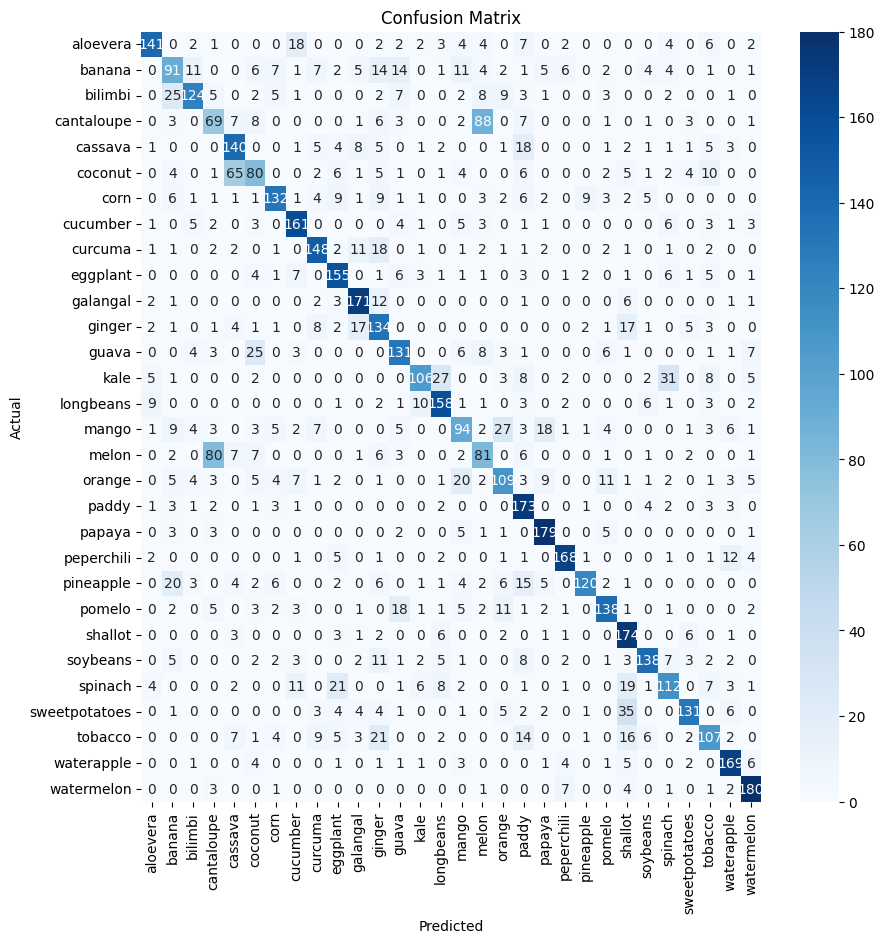

In [12]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    # xtickrotation=45,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
